In [1]:
from blochstate1d_NEW import OLConstants
import numpy as np
from ga_tools import fitness_finder
from genetic_algorithm import full_genetic_algorithm


In [2]:
#initialise constants and parameters
constants = OLConstants()
N_individuals = OLConstants.N_individuals  # Number of individuals in the population
N_elements = OLConstants.N_elements      # Number of elements in the control function (e.g., number
sigma = 100 #standard deviation for the normal distribution to generate the coefficients from
mom_pop_des = constants.desired_mom_pop #desired momentum population from the constants file
mom_pop_des = np.array(mom_pop_des) #convert to numpy array for easier calculations
number_dead = 4 #number of individuals to remove each generation

#Initialise starting coeffs for guess shaking function
A_coeffs = np.random.normal(0, sigma, (N_individuals, N_elements)) #generating the A coefficients from a normal distribution
B_coeffs = np.random.normal(0, sigma, (N_individuals, N_elements)) #generating the B coefficients from a normal distribution
omegas = np.random.uniform(0, 0.6, (N_individuals, N_elements)) #generating the frequencies from a uniform distribution between 0 and 0.6

In [3]:
#This is the first run of the full genetic algorithm, which will return the best fitness of each generation in a list
bestfits, bestAs, bestBs, bestOmegas, final_mom_pop = full_genetic_algorithm(A_coeffs, B_coeffs, omegas, mom_pop_des, number_dead)
best_fit_run1 = np.min(bestfits)
print(f"Best fitness from run 1: {best_fit_run1}")

1000
20
Making controls for individual 1
Propagation Start
Propagation Done
Fitness for individual 1: 0.504401
Making controls for individual 2
Propagation Start
Propagation Done
Fitness for individual 2: 0.652090
Making controls for individual 3
Propagation Start
Propagation Done
Fitness for individual 3: 0.606023
Making controls for individual 4
Propagation Start
Propagation Done
Fitness for individual 4: 0.671636
Making controls for individual 5
Propagation Start
Propagation Done
Fitness for individual 5: 0.567035
Making controls for individual 6
Propagation Start
Propagation Done
Fitness for individual 6: 0.428679
Making controls for individual 7
Propagation Start
Propagation Done
Fitness for individual 7: 0.612972
Making controls for individual 8
Propagation Start
Propagation Done
Fitness for individual 8: 0.521431
Making controls for individual 9
Propagation Start
Propagation Done
Fitness for individual 9: 0.480733
Making controls for individual 10
Propagation Start
Propagation D

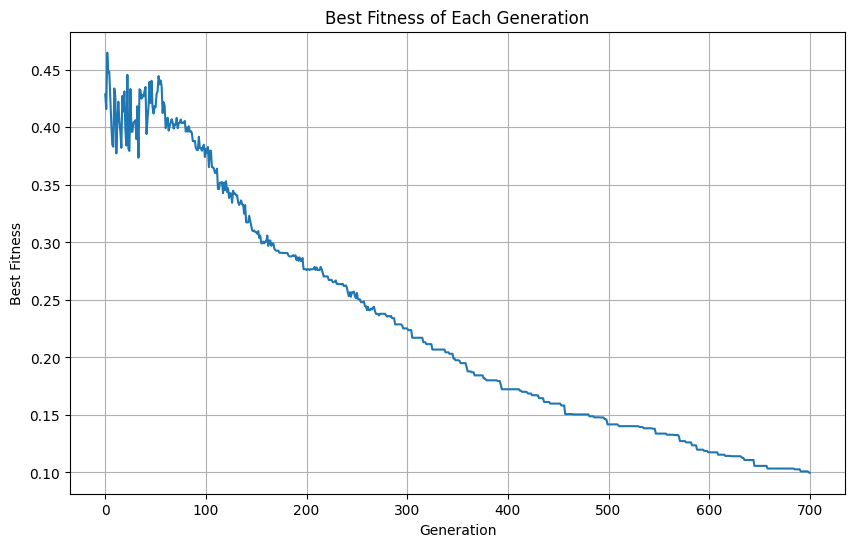

In [4]:
import matplotlib.pyplot as plt
# Plotting the best fitness of each generation
plt.figure(figsize=(10, 6))
plt.plot(bestfits, marker='none')
plt.title('Best Fitness of Each Generation')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.grid()
plt.show()


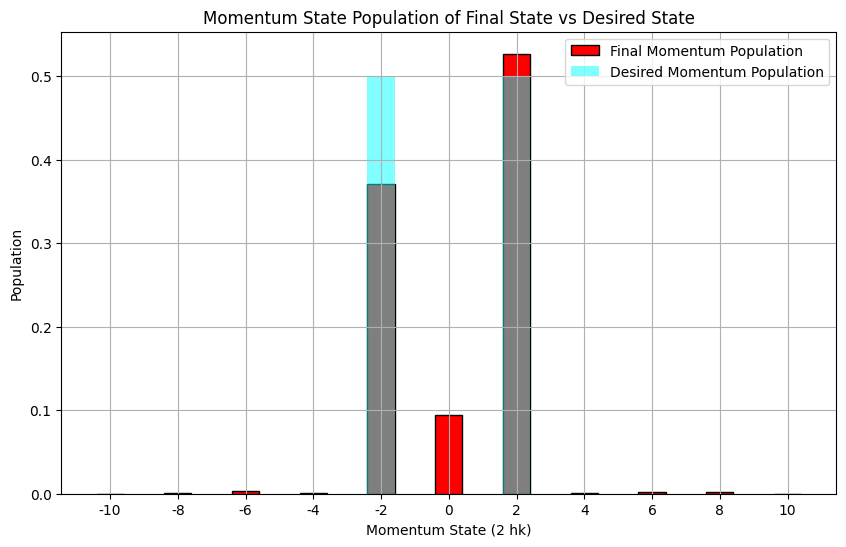

In [6]:
#plotting final momentum state and overlaying the desired momentum state
momentum_idx = np.arange(-10, 12, 2)

plt.figure(figsize=(10, 6))
plt.xticks(momentum_idx, [str(int(x)) for x in momentum_idx])
plt.bar(momentum_idx, final_mom_pop, alpha=1.0, label='Final Momentum Population', color='red', edgecolor='black', linewidth=1)
plt.bar(momentum_idx, mom_pop_des, alpha=0.5, label='Desired Momentum Population', color = 'cyan')
plt.title('Momentum State Population of Final State vs Desired State')
plt.xlabel('Momentum State (2 hk)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()
